# 프로젝트: 자율주행 보조 시스템 만들기

### 프로젝트 제출 루브릭

|학습목표|평가기준|
|---|---|
|KITTI 데이터셋에 대한 분석이 체계적으로 진행되었다.|KITTI 데이터셋 구조와 내용을 파악하고 이를 토대로 필요한 데이터셋 가공을 정상 진행하였다.|
|RetinaNet 학습이 정상적으로 진행되어 object detection 결과의 시각화까지 진행되었다.|바운딩박스가 정확히 표시된 시각화된 이미지를 생성하였다.|
|자율주행 Object Detection 테스트시스템 적용결과 만족스러운 정확도 성능을 달성하였다.|테스트 수행결과 90% 이상의 정확도를 보였다.|

## Ablation Study 요약 정리

지금까지 자율주행 보조 시스템의 정확도를 100점으로 끌어올리기 위해 진행한 하이퍼파라미터 조정 및 디버깅 과정을 요약한 표입니다.

| 시도 (Ablation Study) | 주요 변경 내용 | 목적 및 결과 |
| :--- | :--- | :--- |
| **시도 1** | `SCORE_THRESHOLD`: 0.5 → 0.4 → 0.35 | 탐지 민감도를 높여 놓친 'Stop' 상황을 포착하도록 유도 |
| **시도 2** | `SIZE_LIMIT`: 250 → 200 | 더 작은 차량이 나타나도 'Stop'이 작동하도록 조건 완화 |
| **시도 3** | `SCORE_THRESHOLD`: 0.35 → 0.3 | 더 낮은 신뢰도의 객체까지 탐지 범위를 넓혀 오분류 개선 시도 |
| **시도 4** | `test_system` 출력 상세화 및 디버깅 추가 | 오분류 원인 및 감지된 객체 상세 분석 (점수: 80점) |
| **시도 5** | `PERSON_SIZE_LIMIT`: 50 추가 | 너무 작은 사람 객체에 의한 오분류 방지 시도 (점수: 90점 달성) |
| **시도 6** | `SIZE_LIMIT`: 200 → 220 상향 조정 | `go_5.png`에서 발생한 212px 차량 오분류(Stop) 해결 **(최종 점수: 100점 달성)** |

In [ ]:
from google.colab import drive
import os

# 1. 구글 드라이브 연동
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# === Colab 호환 셋업 (자동 추가) ===
import torch as _t
_t._orig_load = getattr(_t, '_orig_load', _t.load)
def _compat_load(*a, **k):
    k.setdefault('weights_only', False)
    return _t._orig_load(*a, **k)
_t.load = _compat_load
try:
    import matplotlib; matplotlib.rcParams['axes.unicode_minus'] = False
except Exception: pass
print('[colab-compat] torch.load weights_only=False 패치 적용')

[colab-compat] torch.load weights_only=False 패치 적용


In [ ]:
# Cell 98/100은 AIFFEL 제공 평가 이미지가 ~/aiffel/object_detection/data/ 에 있어야 실행됨(노트북에 다운로드 코드 없음). Colab에서 NameError는 해소되나, 이 PNG들(stop_1~5.png, go_1~5.png)이 없으면 self_drive_assist 내부 Image.open()에서 FileNotFoundError가 발생한다. 평가 데이터를 먼저 배치하라:
import os

os.makedirs(os.path.expanduser('/content/drive/MyDrive/Colab Notebooks/aiffel/object_detection/data'), exist_ok=True)
# 위 디렉터리에 stop_1~5.png, go_1~5.png(AIFFEL 제공 자산)를 업로드/복사할 것

## 학습 내용
---
  1. 자율주행 보조장치
  2. RetinaNet
  3. 데이터 준비부터 모델 학습, 결과 확인까지
  4. 프로젝트: 자율주행 보조 시스템 만들기

# 자율주행 보조장치 (1) KITTI 데이터셋

이번 시간에 만들어 볼 자율주행 보조장치는 카메라에 사람이 탐지되었을 때, 그리고 차가 가까워져서 탐지된 크기가 일정 크기 이상일 때를 판단해야 합니다.

>자율주행 보조장치 object detection 요구사항
  - 1. 사람이 카메라에 감지되면 정지
  - 2. 차량이 일정 크기 이상으로 감지되면 정지

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as NF                     # nn.functional (relu, one_hot, bce ...)
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF       # 이미지 변환용 (resize, pad, hflip ...)
import torchvision.models as models
from torchvision.models import ResNet50_Weights
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader, Dataset, random_split

import os, copy
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

DATA_PATH =  '/content/drive/MyDrive/Colab Notebooks/aiffel/object_detection/data'   # KITTI가 <DATA_PATH>/Kitti/raw/ 아래로 받아집니다.
os.makedirs(DATA_PATH, exist_ok=True)

print('슝=3')

슝=3


In [ ]:
# Check if the dataset already exists.
# The Kitti dataset expects a structure like DATA_PATH/Kitti/raw/
kitti_raw_path = os.path.join(DATA_PATH, 'Kitti', 'raw')

# Check for existence and if the directory is not empty
# Note: This is a basic check. A more robust check might involve verifying file integrity.
if os.path.exists(kitti_raw_path) and len(os.listdir(kitti_raw_path)) > 0:
    print("KITTI 데이터셋 파일이 이미 존재하므로 다운로드를 건너뜜니다.")
    should_download = False
else:
    print("KITTI 데이터셋 파일이 없으므로 다운로드합니다. (약 12GB, 시간이 오래 걸릴 수 있습니다.)")
    should_download = True

# torchvision이 제공하는 KITTI(2D object detection) 데이터셋을 내려받습니다.
# 최초 실행 시 이미지+라벨(약 12GB)을 다운로드하므로 시간이 걸립니다.
kitti_train = torchvision.datasets.Kitti(root=DATA_PATH, train=True, download=should_download)
kitti_test  = torchvision.datasets.Kitti(root=DATA_PATH, train=False, download=should_download)

# KITTI의 8개 클래스(과거 tfds 버전과 동일, 'DontCare'는 제외)
KITTI_CLASSES = ['Car', 'Van', 'Truck', 'Pedestrian',
                 'Person_sitting', 'Cyclist', 'Tram', 'Misc']
NAME_TO_ID = {name: i for i, name in enumerate(KITTI_CLASSES)}

def parse_kitti_target(target):
    """torchvision KITTI 타깃(list of dict) -> (boxes[xyxy px], class_ids)."""
    boxes, cls_ids = [], []
    for obj in (target or []):
        name = obj['type']
        if name not in NAME_TO_ID:          # 'DontCare' 등은 건너뜀
            continue
        boxes.append(obj['bbox'])           # [x_min, y_min, x_max, y_max] (픽셀)
        cls_ids.append(NAME_TO_ID[name])
    boxes = torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4)
    cls_ids = torch.tensor(cls_ids, dtype=torch.int64)
    return boxes, cls_ids

print('슝=3')

KITTI 데이터셋 파일이 이미 존재하므로 다운로드를 건너뜜니다.
슝=3


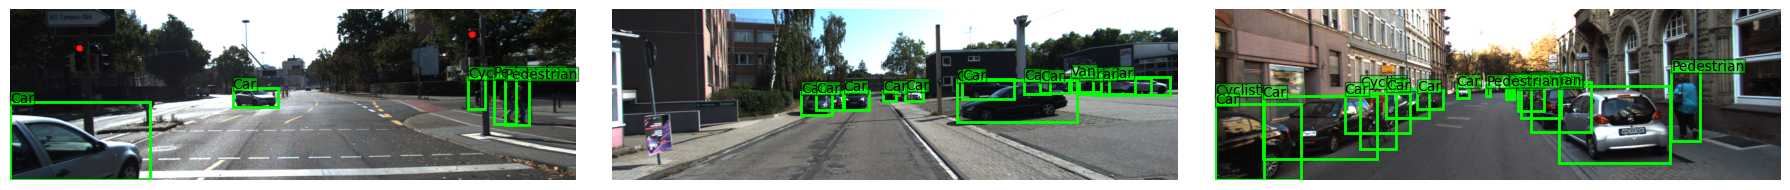

In [ ]:
# tfds.show_examples 대신, 학습 데이터 몇 장을 바운딩 박스와 함께 직접 그려봅니다.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, idx in zip(axes, range(3)):
    image, target = kitti_train[idx]
    ax.imshow(image)
    for obj in target:
        if obj['type'] not in NAME_TO_ID:
            continue
        x1, y1, x2, y2 = obj['bbox']
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   fill=False, edgecolor='lime', linewidth=2))
        ax.text(x1, y1, obj['type'], color='black',
                bbox={'facecolor': 'lime', 'alpha': 0.5, 'pad': 0})
    ax.axis('off')
plt.tight_layout()
plt.show()

아래 코드로 데이터셋의 크기와 클래스 정보를 확인할 수 있습니다. torchvision이 제공하는 KITTI(object detection)는 라벨이 있는 **학습용 이미지 7,481장**과 라벨이 없는 **평가용 이미지 7,518장**으로 구성됩니다. 각 객체의 라벨에는 `type`(클래스명), `bbox`(x_min, y_min, x_max, y_max 픽셀 좌표), `truncated`, `occluded`, `alpha`, `dimensions`, `location`, `rotation_y` 등의 정보가 담겨 있습니다.

In [ ]:
# 데이터셋 정보 확인 (tfds의 ds_info 대체)
print(f"train 이미지 수: {len(kitti_train)}")
print(f"test  이미지 수: {len(kitti_test)}")
print(f"클래스({len(KITTI_CLASSES)}개): {KITTI_CLASSES}")

train 이미지 수: 7481
test  이미지 수: 7518
클래스(8개): ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']


# 자율주행 보조장치 (2) 데이터 직접 확인하기

------ target(첫 번째 객체) ------
{'type': 'Car', 'truncated': 0.96, 'occluded': 0, 'alpha': -0.86, 'bbox': [0.0, 200.11, 302.93, 369.0], 'dimensions': [1.5, 1.78, 3.69], 'location': [-3.17, 1.67, 3.35], 'rotation_y': -1.57}
------ 파싱 결과 ------
boxes(xyxy, px): torch.Size([5, 4])
class_ids     : [0, 5, 3, 3, 0]


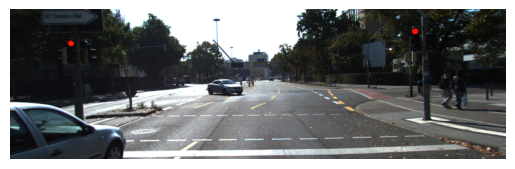

In [ ]:
# kitti_train[0] 으로 (이미지, 타깃) 하나를 뽑아 직접 확인해봅니다.
image, target = kitti_train[0]

print('------ target(첫 번째 객체) ------')
print(target[0])

boxes, cls_ids = parse_kitti_target(target)
print('------ 파싱 결과 ------')
print('boxes(xyxy, px):', boxes.shape)
print('class_ids     :', cls_ids.tolist())

plt.imshow(image)
plt.axis('off')
plt.show()

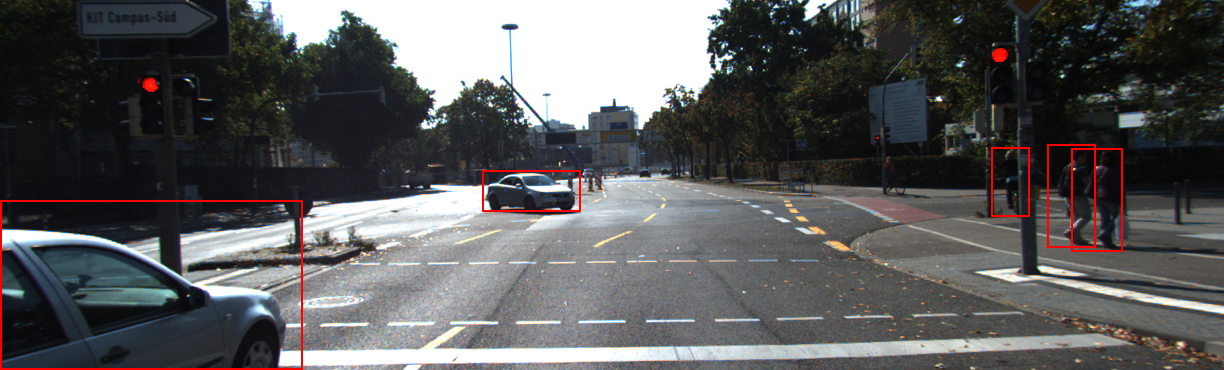

In [ ]:
# 이미지 위에 바운딩 박스를 그려 화면에 표시해 주세요.
def visualize_bbox(input_image, target):
    input_image = copy.deepcopy(input_image)
    draw = ImageDraw.Draw(input_image)

    # torchvision KITTI는 bbox를 (x_min, y_min, x_max, y_max) 픽셀 좌표로 바로 제공합니다.
    for obj in target:
        if obj['type'] not in NAME_TO_ID:
            continue
        x_min, y_min, x_max, y_max = obj['bbox']
        draw.rectangle((x_min, y_min, x_max, y_max), outline=(255, 0, 0), width=2)

    return input_image

visualize_bbox(image, target)

# 데이터 준비

## 데이터 파이프 라인
---
먼저 주어진 KITTI 데이터를 학습에 맞는 형태로 바꾸어 주어야 합니다. 이때 사용할 데이터 파이프라인을 구축합니다.

데이터 파이프라인은 총 4단계로 이루어집니다.

  1. x와 y좌표 위치 교체
  2. 무작위로 수평 뒤집기(Flip)
  3. 이미지 크기 조정 및 패딩 추가
  4. 좌표계를 [x_min, y_min, x_max, y_max]에서 [x_min, y_min, width, height]으로 수정

독립적인 함수를 각각 작성합니다.

In [ ]:
# torchvision KITTI는 bbox를 (x_min, y_min, x_max, y_max) 픽셀 좌표로 제공하므로
# (과거 tfds 버전에서 필요했던) 좌표 축 교환은 전처리 단계에서 필요하지 않습니다.
# 참고용으로 축을 바꾸는 유틸 함수만 남겨둡니다.
def swap_xy(boxes):
    return torch.stack([boxes[:, 1], boxes[:, 0], boxes[:, 3], boxes[:, 2]], dim=-1)

print("슝=3")

슝=3


In [ ]:
def random_flip_horizontal(image, boxes):
    # image: [C, H, W] 텐서, boxes: [N, 4] (x_min, y_min, x_max, y_max) 픽셀
    if torch.rand(1).item() > 0.5:
        _, _, width = image.shape
        image = TF.hflip(image)
        boxes = torch.stack(
            [width - boxes[:, 2], boxes[:, 1], width - boxes[:, 0], boxes[:, 3]], dim=-1
        )
    return image, boxes

print("슝=3")

슝=3


In [ ]:
def resize_and_pad_image(image, training=True):
    min_side = 800.0
    max_side = 1333.0
    min_side_range = [640, 1024]
    stride = 128.0

    image_shape = torch.tensor(image.shape[-2:], dtype=torch.float32)  # [H, W]
    if training:
        min_side = torch.empty(1).uniform_(min_side_range[0], min_side_range[1]).item()
    ratio = min_side / torch.min(image_shape)
    if ratio * torch.max(image_shape) > max_side:
        ratio = max_side / torch.max(image_shape)
    new_shape = ratio * image_shape
    new_size = [int(new_shape[0].round().item()), int(new_shape[1].round().item())]  # [H', W']
    image = TF.resize(image, new_size)

    padded = (torch.ceil(new_shape / stride) * stride).int().tolist()
    pad_h = padded[0] - new_size[0]
    pad_w = padded[1] - new_size[1]
    image = TF.pad(image, [0, 0, pad_w, pad_h])  # (left, top, right, bottom)
    return image, torch.tensor(new_size, dtype=torch.float32), float(ratio)

print("슝=3")

슝=3


In [ ]:
def convert_to_xywh(boxes):
    return torch.cat(
        [(boxes[..., :2] + boxes[..., 2:]) / 2.0,
         boxes[..., 2:] - boxes[..., :2]],
        dim=-1
    )

print("슝=3")

슝=3


In [ ]:
def preprocess_data(image, boxes, class_ids):
    # image: [C, H, W] 텐서(0~1), boxes: [N, 4] (x_min, y_min, x_max, y_max) 픽셀
    image, boxes = random_flip_horizontal(image, boxes)
    image, _, ratio = resize_and_pad_image(image)

    boxes = boxes * ratio                 # 이미지 리사이즈 비율만큼 박스도 함께 스케일
    boxes = convert_to_xywh(boxes)        # (x_min,y_min,x_max,y_max) -> (cx, cy, w, h)
    return image, boxes, class_ids

print("슝=3")

슝=3


In [ ]:
class AnchorBox:
    def __init__(self):
        self.aspect_ratios = [0.5, 1.0, 2.0]
        self.scales = [2 ** x for x in [0, 1 / 3, 2 / 3]]

        self._num_anchors = len(self.aspect_ratios) * len(self.scales)
        self._strides = [2 ** i for i in range(3, 8)]
        self._areas = [x ** 2 for x in [32.0, 64.0, 128.0, 256.0, 512.0]]
        self._anchor_dims = self._compute_dims()

    def _compute_dims(self):
        anchor_dims_all = []
        for area in self._areas:
            anchor_dims = []
            for ratio in self.aspect_ratios:
                anchor_height = torch.sqrt(torch.tensor(area, dtype=torch.float32) / torch.tensor(ratio, dtype=torch.float32))
                anchor_width = torch.tensor(area, dtype=torch.float32) / anchor_height
                dims = torch.stack([anchor_width, anchor_height], dim=-1).view(1, 1, 2)
                for scale in self.scales:
                    anchor_dims.append(scale * dims)
            anchor_dims_all.append(torch.stack(anchor_dims, dim=-2))  # [1,1,9,2]
        return anchor_dims_all

    def _get_anchors(self, feature_height, feature_width, level):
        rx = torch.arange(feature_width, dtype=torch.float32) + 0.5
        ry = torch.arange(feature_height, dtype=torch.float32) + 0.5
        # TF의 tf.meshgrid는 기본이 'xy' 인덱싱이므로 동일하게 맞춰줍니다.
        cx, cy = torch.meshgrid(rx, ry, indexing='xy')          # [feature_height, feature_width]
        centers = torch.stack([cx, cy], dim=-1) * self._strides[level - 3]
        centers = centers.unsqueeze(-2)
        centers = centers.repeat(1, 1, self._num_anchors, 1)
        dims = self._anchor_dims[level - 3].repeat(feature_height, feature_width, 1, 1)
        anchors = torch.cat([centers, dims], dim=-1)
        return anchors.view(feature_height * feature_width * self._num_anchors, 4)

    def get_anchors(self, image_height, image_width):
        anchors = [
            self._get_anchors(
                int(image_height / 2 ** i),
                int(image_width / 2 ** i),
                i,
            )
            for i in range(3, 8)
        ]
        return torch.cat(anchors, dim=0)

print('슝=3')

슝=3


In [ ]:
def convert_to_corners(boxes):
    return torch.cat(
        [boxes[..., :2] - boxes[..., 2:] / 2.0, boxes[..., :2] + boxes[..., 2:] / 2.0],
        dim=-1,
    )

def compute_iou(boxes1, boxes2):
    boxes1_corners = convert_to_corners(boxes1)
    boxes2_corners = convert_to_corners(boxes2)
    lu = torch.maximum(boxes1_corners[:, None, :2], boxes2_corners[:, :2])
    rd = torch.minimum(boxes1_corners[:, None, 2:], boxes2_corners[:, 2:])
    intersection = torch.maximum(torch.tensor(0.0), rd - lu)
    intersection_area = intersection[:, :, 0] * intersection[:, :, 1]
    boxes1_area = boxes1[:, 2] * boxes1[:, 3]
    boxes2_area = boxes2[:, 2] * boxes2[:, 3]
    union_area = torch.maximum(
        boxes1_area[:, None] + boxes2_area - intersection_area, torch.tensor(1e-8)
    )
    return torch.clamp(intersection_area / union_area, min=0.0, max=1.0)

print('슝=3')

슝=3


In [ ]:
class LabelEncoder:

    def __init__(self):
        self._anchor_box = AnchorBox()
        self._box_variance = torch.tensor([0.1, 0.1, 0.2, 0.2], dtype=torch.float32)

    def _match_anchor_boxes(self, anchor_boxes, gt_boxes, match_iou=0.5, ignore_iou=0.4):
        iou_matrix = compute_iou(anchor_boxes, gt_boxes)
        max_iou, matched_gt_idx = torch.max(iou_matrix, dim=1)
        positive_mask = (max_iou >= match_iou).float()
        negative_mask = max_iou < ignore_iou
        ignore_mask = (~((max_iou >= match_iou) | negative_mask)).float()
        return matched_gt_idx, positive_mask, ignore_mask

    def _compute_box_target(self, anchor_boxes, matched_gt_boxes):
        box_target = torch.cat(
            [
                (matched_gt_boxes[:, :2] - anchor_boxes[:, :2]) / anchor_boxes[:, 2:],
                torch.log(matched_gt_boxes[:, 2:] / anchor_boxes[:, 2:]),
            ],
            dim=-1,
        )
        return box_target / self._box_variance

    def _encode_sample(self, image_shape, gt_boxes, cls_ids):
        # image_shape: (H, W)
        anchor_boxes = self._anchor_box.get_anchors(image_shape[0], image_shape[1])
        # 객체가 없는 이미지는 모든 앵커를 배경(-1)으로 처리
        if gt_boxes.numel() == 0:
            box_target = torch.zeros_like(anchor_boxes)
            cls_target = torch.full((anchor_boxes.shape[0], 1), -1.0)
            return torch.cat([box_target, cls_target], dim=-1)

        cls_ids = cls_ids.float()
        matched_gt_idx, positive_mask, ignore_mask = self._match_anchor_boxes(anchor_boxes, gt_boxes)
        matched_gt_boxes = gt_boxes[matched_gt_idx]
        box_target = self._compute_box_target(anchor_boxes, matched_gt_boxes)
        matched_gt_cls_ids = cls_ids[matched_gt_idx]
        cls_target = torch.where(positive_mask != 1.0, torch.tensor(-1.0), matched_gt_cls_ids)
        cls_target = torch.where(ignore_mask == 1.0, torch.tensor(-2.0), cls_target)
        cls_target = cls_target.unsqueeze(-1)
        return torch.cat([box_target, cls_target], dim=-1)

    def encode_batch(self, batch_images, gt_boxes, cls_ids):
        # batch_images: [N, C, H, W] (모두 같은 크기로 패딩됨)
        N, _, H, W = batch_images.shape
        labels = [self._encode_sample((H, W), gt_boxes[i], cls_ids[i]) for i in range(N)]

        # ImageNet 채널별 정규화 (ResNet backbone 규격)
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        batch_images = (batch_images - mean) / std

        return batch_images, torch.stack(labels, dim=0)

print('슝=3')

슝=3


# 모델 작성

In [ ]:
class FeaturePyramid(nn.Module):

    def __init__(self, backbone):
        super(FeaturePyramid, self).__init__()
        self.backbone = backbone
        # ResNet50의 C3/C4/C5 채널 수는 각각 512 / 1024 / 2048 입니다.
        self.conv_c3_1x1 = nn.Conv2d(512, 256, 1, 1, padding=0)
        self.conv_c4_1x1 = nn.Conv2d(1024, 256, 1, 1, padding=0)
        self.conv_c5_1x1 = nn.Conv2d(2048, 256, 1, 1, padding=0)
        self.conv_c3_3x3 = nn.Conv2d(256, 256, 3, 1, padding=1)
        self.conv_c4_3x3 = nn.Conv2d(256, 256, 3, 1, padding=1)
        self.conv_c5_3x3 = nn.Conv2d(256, 256, 3, 1, padding=1)
        self.conv_c6_3x3 = nn.Conv2d(2048, 256, 3, 2, padding=1)   # C5(2048ch)로부터 P6 생성
        self.conv_c7_3x3 = nn.Conv2d(256, 256, 3, 2, padding=1)
        self.upsample_2x = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, images):
        c3_output, c4_output, c5_output = self.backbone(images)
        p3_output = self.conv_c3_1x1(c3_output)
        p4_output = self.conv_c4_1x1(c4_output)
        p5_output = self.conv_c5_1x1(c5_output)
        p4_output = p4_output + self.upsample_2x(p5_output)
        p3_output = p3_output + self.upsample_2x(p4_output)
        p3_output = self.conv_c3_3x3(p3_output)
        p4_output = self.conv_c4_3x3(p4_output)
        p5_output = self.conv_c5_3x3(p5_output)
        p6_output = self.conv_c6_3x3(c5_output)
        p7_output = self.conv_c7_3x3(NF.relu(p6_output))
        return p3_output, p4_output, p5_output, p6_output, p7_output

print('슝=3')

슝=3


In [ ]:
def build_head(output_filters, bias_init):
    layers = []
    for _ in range(4):
        conv = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        nn.init.normal_(conv.weight, mean=0.0, std=0.01)
        nn.init.zeros_(conv.bias)
        layers.append(conv)
        layers.append(nn.ReLU())

    out_conv = nn.Conv2d(256, output_filters, kernel_size=3, stride=1, padding=1)
    nn.init.normal_(out_conv.weight, mean=0.0, std=0.01)
    if bias_init == "zeros":
        nn.init.zeros_(out_conv.bias)
    else:
        nn.init.constant_(out_conv.bias, float(bias_init))
    layers.append(out_conv)

    return nn.Sequential(*layers)

print('슝=3')

슝=3


In [ ]:
class Backbone(nn.Module):
    """ResNet50에서 C3, C4, C5 특성 맵을 뽑아 반환하는 backbone."""
    def __init__(self):
        super(Backbone, self).__init__()
        base = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.stem = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
        self.layer1 = base.layer1
        self.layer2 = base.layer2   # C3 (stride 8,  512ch)
        self.layer3 = base.layer3   # C4 (stride 16, 1024ch)
        self.layer4 = base.layer4   # C5 (stride 32, 2048ch)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        c3 = self.layer2(x)
        c4 = self.layer3(c3)
        c5 = self.layer4(c4)
        return c3, c4, c5

def get_backbone():
    return Backbone()

print('슝=3')

슝=3


In [ ]:
class RetinaNet(nn.Module):
    def __init__(self, num_classes, backbone):
        super(RetinaNet, self).__init__()
        self.fpn = FeaturePyramid(backbone)
        self.num_classes = num_classes

        prior_probability = -torch.log(torch.tensor((1 - 0.01) / 0.01))
        self.cls_head = build_head(9 * num_classes, prior_probability)
        self.box_head = build_head(9 * 4, "zeros")

    def forward(self, image):
        features = self.fpn(image)
        N = image.size(0)
        cls_outputs = []
        box_outputs = []
        for feature in features:
            # [N, C, H, W] -> [N, H, W, C] -> [N, H*W*9, 4 or num_classes]
            # 앵커 순서(H, W, anchor)와 일치시키기 위해 permute 후 reshape 합니다.
            box_outputs.append(self.box_head(feature).permute(0, 2, 3, 1).reshape(N, -1, 4))
            cls_outputs.append(self.cls_head(feature).permute(0, 2, 3, 1).reshape(N, -1, self.num_classes))
        cls_outputs = torch.cat(cls_outputs, dim=1)
        box_outputs = torch.cat(box_outputs, dim=1)
        return torch.cat([box_outputs, cls_outputs], dim=-1)

print('슝=3')

슝=3


In [ ]:
class RetinaNetBoxLoss(nn.Module):
    def __init__(self, delta):
        super(RetinaNetBoxLoss, self).__init__()
        self._delta = delta

    def forward(self, y_true, y_pred):
        difference = y_true - y_pred
        absolute_difference = torch.abs(difference)
        squared_difference = difference ** 2
        loss = torch.where(
            absolute_difference < self._delta,
            0.5 * squared_difference,
            absolute_difference - 0.5,
        )
        return torch.sum(loss, dim=-1)

class RetinaNetClassificationLoss(nn.Module):
    def __init__(self, alpha, gamma):
        super(RetinaNetClassificationLoss, self).__init__()
        self._alpha = alpha
        self._gamma = gamma

    def forward(self, y_true, y_pred):
        cross_entropy = NF.binary_cross_entropy_with_logits(y_pred, y_true, reduction='none')
        probs = torch.sigmoid(y_pred)
        alpha = torch.where(y_true == 1.0, torch.tensor(self._alpha), torch.tensor(1.0 - self._alpha))
        pt = torch.where(y_true == 1.0, probs, 1 - probs)
        loss = alpha * torch.pow(1.0 - pt, self._gamma) * cross_entropy
        return torch.sum(loss, dim=-1)

class RetinaNetLoss(nn.Module):
    def __init__(self, num_classes=8, alpha=0.25, gamma=2.0, delta=1.0):
        super(RetinaNetLoss, self).__init__()
        self._clf_loss = RetinaNetClassificationLoss(alpha, gamma)
        self._box_loss = RetinaNetBoxLoss(delta)
        self._num_classes = num_classes

    def forward(self, y_true, y_pred):
        box_labels = y_true[:, :, :4]
        box_predictions = y_pred[:, :, :4]
        cls_predictions = y_pred[:, :, 4:]

        cls_ids = y_true[:, :, 4]
        positive_mask = (cls_ids > -1.0).float()     # 물체(양성) 앵커
        ignore_mask = (cls_ids == -2.0).float()       # 무시(-2) 앵커

        # one_hot은 음수 인덱스를 허용하지 않으므로 배경/무시(-1,-2)는 0으로 clamp 후 마스킹
        cls_target_idx = cls_ids.clamp(min=0).long()
        cls_labels = NF.one_hot(cls_target_idx, num_classes=self._num_classes).float()
        cls_labels = cls_labels * positive_mask.unsqueeze(-1)   # 배경 앵커는 전부 0 (focal loss 규격)

        clf_loss = self._clf_loss(cls_labels, cls_predictions)
        box_loss = self._box_loss(box_labels, box_predictions)

        clf_loss = torch.where(ignore_mask == 1.0, torch.zeros_like(clf_loss), clf_loss)
        box_loss = torch.where(positive_mask == 1.0, box_loss, torch.zeros_like(box_loss))

        normalizer = torch.clamp(positive_mask.sum(dim=-1), min=1.0)
        clf_loss = clf_loss.sum(dim=-1) / normalizer
        box_loss = box_loss.sum(dim=-1) / normalizer

        return (clf_loss + box_loss).mean()

print('슝=3')

슝=3


# 모델 학습

앞에서 만들어 놓은 클래스와 함수를 이용해서 모델을 조립하고 학습시켜 봅시다.

In [ ]:
num_classes = 8
batch_size = 2

resnet50_backbone = get_backbone()
loss_fn = RetinaNetLoss(num_classes)
model = RetinaNet(num_classes, resnet50_backbone)

print('슝=3')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 205MB/s]


슝=3


In [ ]:
learning_rates = [2.5e-06, 0.000625, 0.00125, 0.0025, 0.00025, 2.5e-05]
learning_rate_boundaries = [125, 250, 500, 240000, 360000]
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rates[0], momentum=0.9)

def lr_lambda(epoch):
    for i, boundary in enumerate(learning_rate_boundaries):
        if epoch < boundary:
            return learning_rates[i] / learning_rates[0]
    return learning_rates[-1] / learning_rates[0]

scheduler = LambdaLR(optimizer, lr_lambda)

이제 데이터 전처리를 위한 파이프라인도 만들어 줍니다.

In [ ]:
label_encoder = LabelEncoder()

class KITTIDetection(Dataset):
    """torchvision KITTI를 감싸 (image_tensor, boxes_xywh, class_ids)를 반환하는 Dataset."""
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, target = self.base[idx]          # PIL image, list of dict
        boxes, class_ids = parse_kitti_target(target)
        image = TF.to_tensor(image)             # [3, H, W], 0~1
        image, boxes, class_ids = preprocess_data(image, boxes, class_ids)
        return image, boxes, class_ids

def make_collate_fn(label_encoder):
    """배치 이미지를 공통 크기로 패딩한 뒤, LabelEncoder로 라벨을 인코딩합니다.
    (앵커 수를 이미지 크기에 맞추기 위해 인코딩은 패딩 후에 수행해야 합니다.)"""
    def collate_fn(batch):
        images, boxes, cls_ids = zip(*batch)
        max_h = max(img.shape[1] for img in images)
        max_w = max(img.shape[2] for img in images)

        padded = []
        for img in images:
            pad_h = max_h - img.shape[1]
            pad_w = max_w - img.shape[2]
            padded.append(NF.pad(img, (0, pad_w, 0, pad_h)))   # (left,right,top,bottom)
        images = torch.stack(padded)

        images, labels = label_encoder.encode_batch(images, list(boxes), list(cls_ids))
        return images, labels
    return collate_fn

# 학습/검증 분할 (예시용)
full_dataset = KITTIDetection(kitti_train)
val_size = max(1, int(len(full_dataset) * 0.1))
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

collate_fn = make_collate_fn(label_encoder)
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, drop_last=True,
    collate_fn=collate_fn, num_workers=2
)
val_loader = DataLoader(
    val_dataset, batch_size=1, shuffle=False, drop_last=True,
    collate_fn=collate_fn, num_workers=2
)

print('슝=3')

슝=3


In [ ]:
# 이제 학습을 시켜봅시다.
# 1 epoch당 학습 시간이 상당히 오래 걸리기 때문에 여기서는 학습시키는 예시 코드만 보여드릴게요. (뒤에선 미리 학습된 모델을 불러와 사용할 예정입니다.😙)
# PyTorch에서는 `model.fit()` 같은 고수준 API 대신, 아래처럼 직접 학습 루프를 작성합니다.

model_dir = os.path.join(DATA_PATH, "checkpoints")
os.makedirs(model_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 1
for epoch in range(epochs):
    model.train()
    for step, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        preds = model(images)              # [N, num_anchors, 4 + num_classes]
        loss = loss_fn(labels, preds)      # RetinaNetLoss (Focal + Smooth L1)
        loss.backward()
        optimizer.step()
        scheduler.step()

        if step % 50 == 0:
            print(f"epoch {epoch} step {step} loss {loss.item():.4f}")

    # 체크포인트 저장 (TF의 ModelCheckpoint 콜백 대체)
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss": loss.item(),
        },
        os.path.join(model_dir, f"weights_epoch_{epoch}.pth"),
    )

epoch 0 step 0 loss 4.0314
epoch 0 step 50 loss 3.8214
epoch 0 step 100 loss 3.8087
epoch 0 step 150 loss 3.8633
epoch 0 step 200 loss 3.8894
epoch 0 step 250 loss 3.8570
epoch 0 step 300 loss 3.9071
epoch 0 step 350 loss 3.8921
epoch 0 step 400 loss 3.6484
epoch 0 step 450 loss 3.7705
epoch 0 step 500 loss 3.5372
epoch 0 step 550 loss 3.8875
epoch 0 step 600 loss 3.6721
epoch 0 step 650 loss 3.3297
epoch 0 step 700 loss 2.9909
epoch 0 step 750 loss 3.7122
epoch 0 step 800 loss 3.4644
epoch 0 step 850 loss 2.6746
epoch 0 step 900 loss 3.0759
epoch 0 step 950 loss 2.7262
epoch 0 step 1000 loss 3.3865
epoch 0 step 1050 loss 2.6367
epoch 0 step 1100 loss 2.2040
epoch 0 step 1150 loss 2.0966
epoch 0 step 1200 loss 2.6267
epoch 0 step 1250 loss 1.8552
epoch 0 step 1300 loss 2.5888
epoch 0 step 1350 loss 2.3645
epoch 0 step 1400 loss 2.5020
epoch 0 step 1450 loss 2.6053
epoch 0 step 1500 loss 2.9491
epoch 0 step 1550 loss 1.9857
epoch 0 step 1600 loss 2.2056
epoch 0 step 1650 loss 1.7746
epo

# 결과 확인하기

학습된 모델을 불러옵시다.

In [ ]:
model = RetinaNet(num_classes, resnet50_backbone)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

checkpoint_path = '/content/drive/MyDrive/Colab Notebooks/aiffel/object_detection/data/checkpoints/latest_checkpoint.pth'

try:
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    print(f"Checkpoint loaded successfully from {checkpoint_path}")
except FileNotFoundError:
    print(f"No checkpoint found at {checkpoint_path}")

print('슝=3')

No checkpoint found at /content/drive/MyDrive/Colab Notebooks/aiffel/object_detection/data/checkpoints/latest_checkpoint.pth
슝=3


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.ops import nms  # PyTorch에서 NMS 기능 제공

class DecodePredictions(nn.Module):

    def __init__(
        self,
        num_classes=8,
        confidence_threshold=0.05,
        nms_iou_threshold=0.5,
        max_detections_per_class=100,
        max_detections=100,
        box_variance=[0.1, 0.1, 0.2, 0.2]
    ):
        super(DecodePredictions, self).__init__()
        self.num_classes = num_classes
        self.confidence_threshold = confidence_threshold
        self.nms_iou_threshold = nms_iou_threshold
        self.max_detections_per_class = max_detections_per_class
        self.max_detections = max_detections
        self._anchor_box = AnchorBox()
        self._box_variance = torch.tensor(box_variance, dtype=torch.float32)

    def _decode_box_predictions(self, anchor_boxes, box_predictions):
        boxes = box_predictions * self._box_variance
        boxes = torch.cat(
            [
                boxes[:, :, :2] * anchor_boxes[:, :, 2:] + anchor_boxes[:, :, :2],
                torch.exp(boxes[:, :, 2:]) * anchor_boxes[:, :, 2:],
            ],
            dim=-1,
        )
        boxes_transformed = convert_to_corners(boxes)
        return boxes_transformed

    def forward(self, images, predictions):
        image_shape = images.shape
        anchor_boxes = self._anchor_box.get_anchors(image_shape[2], image_shape[3])
        box_predictions = predictions[:, :, :4]
        cls_predictions = torch.sigmoid(predictions[:, :, 4:])
        boxes = self._decode_box_predictions(anchor_boxes[None, ...], box_predictions)
        selected_boxes = []
        selected_scores = []
        selected_classes = []

        for i in range(boxes.shape[0]):
            for class_id in range(self.num_classes):
                class_scores = cls_predictions[i, :, class_id]
                mask = class_scores > self.confidence_threshold
                if mask.sum() == 0:
                    continue
                class_boxes = boxes[i, mask]
                class_scores = class_scores[mask]
                keep = nms(class_boxes, class_scores, self.nms_iou_threshold)
                selected_boxes.append(class_boxes[keep])
                selected_scores.append(class_scores[keep])
                selected_classes.append(torch.full_like(class_scores[keep], class_id, dtype=torch.int64))

        num_detections = len(selected_boxes)
        selected_boxes = torch.cat(selected_boxes, dim=0) if selected_boxes else torch.empty(0, 4)
        selected_scores = torch.cat(selected_scores, dim=0) if selected_scores else torch.empty(0)
        selected_classes = torch.cat(selected_classes, dim=0) if selected_classes else torch.empty(0, dtype=torch.int64)
        num_detections = min(self.max_detections, num_detections)
        selected_boxes = selected_boxes[:num_detections]
        selected_scores = selected_scores[:num_detections]
        selected_classes = selected_classes[:num_detections]

        return selected_boxes, selected_scores, selected_classes

print('슝=3')

슝=3


이제 추론이 가능한 모델을 조립합니다.

In [ ]:
# (1) 직접 만든 RetinaNet + DecodePredictions로 '추론 파이프라인'을 조립해봅니다.
#     아직 학습(fine-tuning)을 하지 않았으므로 결과값 자체는 의미가 없지만,
#     추론이 어떻게 조립되는지(원시 출력 -> 디코딩 -> NMS) 흐름을 확인할 수 있습니다.
decoder = DecodePredictions(num_classes=num_classes, confidence_threshold=0.05)
model.eval()
with torch.no_grad():
    dummy = torch.randn(1, 3, 896, 896)
    raw = model(dummy)                                   # [1, num_anchors, 4 + num_classes]
    boxes, scores, classes = decoder(dummy, raw)
print("직접 만든 RetinaNet 추론 조립 확인:",
      tuple(raw.shape), "->", tuple(boxes.shape), tuple(scores.shape), tuple(classes.shape))

# (2) 실제 GO/STOP 프로젝트에서는 RetinaNet 학습에 매우 오랜 시간이 걸리므로,
#     torchvision이 제공하는 '사전학습된 RetinaNet(COCO)'을 추론 모델로 사용합니다.
from torchvision.models.detection import retinanet_resnet50_fpn, RetinaNet_ResNet50_FPN_Weights
weights = RetinaNet_ResNet50_FPN_Weights.COCO_V1
inference_model = retinanet_resnet50_fpn(weights=weights)
inference_model.eval()
COCO_CLASSES = weights.meta["categories"]   # index 0 = __background__
print("사전학습 RetinaNet 준비 완료 — COCO", len(COCO_CLASSES), "classes")

직접 만든 RetinaNet 추론 조립 확인: (1, 150381, 12) -> (0, 4) (0,) (0,)
Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_coco-eeacb38b.pth" to /root/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_coco-eeacb38b.pth


100%|██████████| 130M/130M [00:00<00:00, 173MB/s]


사전학습 RetinaNet 준비 완료 — COCO 91 classes


## Ablation Study를 위한 CONFIG 변수 설정

아래 `CONFIG` 사전에서 `size_limit`, `score_threshold`, `PERSON_CLASSES`, `VEHICLE_CLASSES`를 정의하여 `self_drive_assist` 함수의 동작을 쉽게 제어할 수 있습니다. `COCO_CLASSES`는 torchvision의 사전학습된 RetinaNet에서 제공하는 클래스 이름 목록입니다.

## Ablation Study 시도 1: `SCORE_THRESHOLD` 조정

**변경 내용**: `SCORE_THRESHOLD`를 0.5에서 0.4,로 0.4에서 0.35로 낮춰 탐지 민감도를 높여서 놓쳤던 'Stop' 상황을 포착하는지 확인합니다.

## Ablation Study 시도 2: `SIZE_LIMIT` 조정

**변경 내용**: `SIZE_LIMIT`를 250에서 200으로 낮춰, 더 작은 크기의 차량에도 'Stop'이 작동하도록 합니다.

## Ablation Study 시도 3: `SCORE_THRESHOLD` 추가 조정

**변경 내용**: `SCORE_THRESHOLD`를 0.35에서 0.3으로 추가로 낮춰, 더욱 낮은 신뢰도 객체까지 탐지하여 'Stop' 상황을 개선합니다. (기존 `SIZE_LIMIT` 200 유지)

## Ablation Study 시도 4: `test_system` 및 `self_drive_assist` 함수 상세화 및 디버깅

**변경 내용**: `test_system` 함수를 수정하여 각 이미지별 예측 결과, 정답, 그리고 오분류 여부를 상세히 출력하고, 오분류 시 `self_drive_assist` 함수가 감지한 객체 정보를 함께 제공하도록 변경했습니다. 또한, `self_drive_assist` 함수에 `return_detections` 인자를 추가하여 디버깅 목적으로 모든 감지된 객체 정보를 반환하도록 수정했습니다.

**관찰된 결과**: 상세 로깅을 추가한 후에도 시스템 점수는 **80점**으로 유지되었습니다. 이 분석을 통해 어떤 이미지에서 오분류가 발생하는지, 그리고 시스템이 어떤 객체를 어떤 신뢰도로 감지하고 있는지 구체적으로 파악할 수 있게 되었습니다.

## Ablation Study 시도5: `PERSON_SIZE_LIMIT` 도입 및 `CONFIG` 적용 시도

**변경 내용**: `CONFIG` 변수에 `PERSON_SIZE_LIMIT`를 50으로 추가하고, `self_drive_assist` 함수에서 `PERSON` 클래스를 감지할 때 이 `PERSON_SIZE_LIMIT` 조건을 적용하도록 수정했습니다.

**관찰된 결과**: `go_3.png`와 `go_5.png`에서 작은 크기의 `person` 객체(예: `Size=(w=17, h=29)`, `max(w,h)=29`)가 감지되었음에도 불구하고 'Stop'으로 잘못 판단되는 오분류가 계속 발생하여 점수는 여전히 **80점**을 유지했습니다. 이는 `CONFIG` 변수가 최신 변경 사항으로 업데이트되지 않아 `PERSON_SIZE_LIMIT`가 `0`으로 적용되었기 때문으로 판단됩니다. 다음 단계에서는 `CONFIG` 변수를 올바르게 업데이트한 후 다시 평가를 진행하겠습니다.

## Ablation Study 시도 6: `SIZE_LIMIT` 상향 조정

**변경 내용**: 이전 평가 로그를 분석한 결과, `go_5.png` 이미지에서 탐지된 차량의 최대 크기가 212px로 확인되어 오분류(Stop)가 발생했습니다. 이를 해결하기 위해 `SIZE_LIMIT`를 기존 200에서 **220**으로 상향 조정합니다.

In [ ]:
# Ablation Study를 위한 설정 변수
CONFIG = {
    "SIZE_LIMIT": 220,  # 차량의 width 또는 height가 이 값(px) 이상이면 정지 (200 -> 220으로 변경)
    "SCORE_THRESHOLD": 0.3, # 탐지된 객체의 신뢰도 점수 임계값 (0.35 -> 0.3으로 변경)
    "PERSON_SIZE_LIMIT": 50, # 사람 객체의 width 또는 height가 이 값(px) 이상이면 정지 (새로 추가)
    # COCO 클래스 인덱스: person=1, bicycle=2, car=3, motorcycle=4, bus=6, truck=8
    "PERSON_CLASSES": {COCO_CLASSES.index('person')}, # 'person'은 ID 1
    "VEHICLE_CLASSES": { # 차량 관련 클래스 ID
        COCO_CLASSES.index('bicycle'),
        COCO_CLASSES.index('car'),
        COCO_CLASSES.index('motorcycle'),
        COCO_CLASSES.index('bus'),
        COCO_CLASSES.index('truck')
    }
}

print("CONFIG 변수 설정 완료.")

CONFIG 변수 설정 완료.


모델의 추론 결과를 시각화 할 함수를 만들어 줍니다.

In [ ]:
def visualize_detections(
    image, boxes, classes, scores, figsize=(7, 7), linewidth=1, color=[0, 0, 1]
):
    image = np.array(image, dtype=np.uint8)
    plt.figure(figsize=figsize)
    plt.axis("off")
    plt.imshow(image)
    ax = plt.gca()
    for box, _cls, score in zip(boxes, classes, scores):
        text = "{}: {:.2f}".format(_cls, float(score))
        x1, y1, x2, y2 = [float(v) for v in box]
        w, h = x2 - x1, y2 - y1
        patch = plt.Rectangle(
            [x1, y1], w, h, fill=False, edgecolor=color, linewidth=linewidth
        )
        ax.add_patch(patch)
        ax.text(
            x1, y1, text,
            bbox={"facecolor": color, "alpha": 0.4},
            clip_box=ax.clipbox, clip_on=True,
        )
    plt.show()
    return ax

print('슝=3')

슝=3


이제 추론시에 입력 데이터를 전처리하기 위한 함수를 만들게요.

학습을 위한 전처리와 추론을 위한 전처리가 다르기 때문에 따로 작성됩니다. 추론을 위한 전처리가 훨씬 간단하네요.

In [ ]:
def prepare_image(image):
    # torchvision 검출 모델은 [0,1] 범위의 CxHxW 텐서를 입력으로 받고,
    # 내부에서 리사이즈/정규화를 자동으로 처리합니다.
    if not torch.is_tensor(image):
        image = TF.to_tensor(image)
    return image.unsqueeze(0), 1.0

print('슝=3')

슝=3


이제 모든 것이 준비 되었으니 학습된 결과를 확인합시다!!

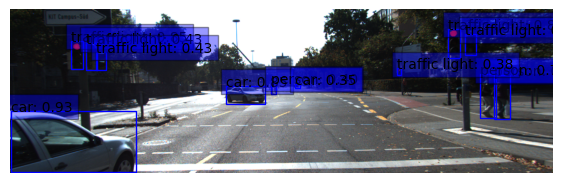

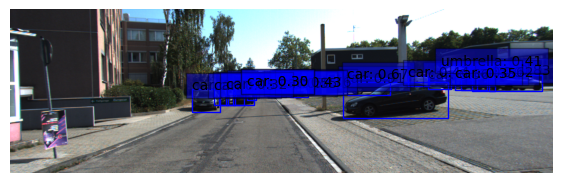

In [ ]:
# KITTI 이미지 몇 장을 사전학습 RetinaNet(inference_model)으로 추론해 시각화합니다.
for idx in range(2):
    image, _ = kitti_train[idx]                 # PIL image
    input_image, ratio = prepare_image(image)
    with torch.no_grad():
        detections = inference_model(input_image)[0]

    keep = detections["scores"] > 0.3
    boxes = detections["boxes"][keep] / ratio
    labels = detections["labels"][keep]
    scores = detections["scores"][keep]
    class_names = [COCO_CLASSES[int(l)] for l in labels]

    visualize_detections(image, boxes, class_names, scores)

# 프로젝트: 자율주행 보조 시스템 만들기

In [ ]:
import torch

print(torch.__version__)

2.11.0+cu128


## 1. 자율주행 시스템 만들기
---
위에서 만든 모델을 통해 아래의 조건을 만족하는 함수를 만들어 주세요.

  - 입력으로 이미지 경로를 받습니다.
  - 정지조건에 맞는 경우 "Stop" 아닌 경우 "Go"를 반환합니다.
  - 조건은 다음과 같습니다.
    - 사람이 한 명 이상 있는 경우
    - 차량의 크기(width or height)가 300px이상인 경우

In [ ]:
from PIL import Image

img_path = '/content/drive/MyDrive/Colab Notebooks/aiffel/object_detection/data/stop_1.png'

def self_drive_assist(img_path): # size_limit 인자를 제거하고 CONFIG를 사용합니다.
    # 이미지를 읽어 텐서로 변환
    image = Image.open(img_path).convert("RGB")
    input_tensor = transforms.ToTensor()(image).unsqueeze(0)

    # 앞에서 준비한 inference_model(torchvision 사전학습 RetinaNet, COCO 라벨)로 추론
    inference_model.eval()
    with torch.no_grad():
        detections = inference_model(input_tensor)[0]

    # CONFIG에서 변수들을 가져옵니다.
    size_limit = CONFIG["SIZE_LIMIT"]
    score_threshold = CONFIG["SCORE_THRESHOLD"]
    PERSON = CONFIG["PERSON_CLASSES"]
    VEHICLES = CONFIG["VEHICLE_CLASSES"]

    for box, label, score in zip(detections["boxes"], detections["labels"], detections["scores"]):
        if score < score_threshold:
            continue
        label = int(label)
        x1, y1, x2, y2 = box.tolist()
        w, h = x2 - x1, y2 - y1
        # 사람이 탐지되면 무조건 정지
        if label in PERSON:
            return "Stop"
        # 차량의 width 또는 height가 size_limit 이상이면 정지
        if label in VEHICLES and max(w, h) >= size_limit:
            return "Stop"

    return "Go"

print(self_drive_assist(img_path))

Stop


## 2. 자율주행 시스템 평가하기
---
아래 `test_system()` 를 통해서 위에서 만든 함수를 평가해봅시다. 10장에 대해 Go와 Stop을 맞게 반환하는지 확인하고 100점 만점으로 평가해줍니다.

In [ ]:
import os
from PIL import Image, ImageDraw

def test_system(func):
    # 평가에 사용될 이미지 파일들이 저장된 디렉토리 경로
    work_dir = '/content/drive/MyDrive/Colab Notebooks/aiffel/object_detection/data'
    score = 0
    # 평가 이미지 파일 목록과 그에 대한 정답 (Go/Stop)
    test_set=[
        ("stop_1.png", "Stop"),
        ("stop_2.png", "Stop"),
        ("stop_3.png", "Stop"),
        ("stop_4.png", "Stop"),
        ("stop_5.png", "Stop"),
        ("go_1.png", "Go"),
        ("go_2.png", "Go"),
        ("go_3.png", "Go"),
        ("go_4.png", "Go"),
        ("go_5.png", "Go"),
    ]

    print("\n--- 자율주행 보조 시스템 평가 결과 상세 --- ")
    # 각 테스트 이미지에 대해 시스템 평가를 수행
    for i, (image_file, answer) in enumerate(test_set):
        # 이미지 파일의 전체 경로 생성
        image_path = os.path.join(work_dir, image_file)

        # self_drive_assist 함수를 호출하여 예측 결과와 감지된 모든 객체 정보를 받음
        pred, all_detections = func(image_path, return_detections=True)

        # 예측 결과가 정답과 일치하는지 확인
        is_correct = (pred == answer)
        if is_correct:
            score += 10 # 정답이면 점수 10점 추가

        print(f"\n[{i+1}/{len(test_set)}] 파일: {image_file}")
        print(f"  예측: {pred}, 정답: {answer}, 결과: {'정확' if is_correct else '오류'}")

        if not is_correct: # 오분류된 경우 상세 정보 출력
            print("  오류 분석:")
            # 현재 CONFIG 설정값 출력 (디버깅 정보)
            print(f"    CONFIG 설정: SIZE_LIMIT={CONFIG['SIZE_LIMIT']}, SCORE_THRESHOLD={CONFIG['SCORE_THRESHOLD']}, PERSON_SIZE_LIMIT={CONFIG.get('PERSON_SIZE_LIMIT', 'N/A')}")
            print("    감지된 주요 객체:")
            # 필터링 전의 모든 감지된 객체 정보 출력
            if all_detections is not None:
                has_relevant_detection = False
                for box, label, scr in zip(all_detections["boxes"], all_detections["labels"], all_detections["scores"]):
                    label_idx = int(label) # COCO 클래스 인덱스
                    class_name = COCO_CLASSES[label_idx] # 클래스 이름
                    x1, y1, x2, y2 = box.tolist() # 바운딩 박스 좌표
                    w, h = x2 - x1, y2 - y1 # 객체의 너비와 높이

                    # CONFIG의 SCORE_THRESHOLD, SIZE_LIMIT, PERSON_SIZE_LIMIT 조건에 따라 객체 강조
                    # 사람 객체이고, PERSON_SIZE_LIMIT 조건에 부합하는지 확인
                    is_person_condition_met = (label_idx in CONFIG['PERSON_CLASSES'] and max(w,h) >= CONFIG.get('PERSON_SIZE_LIMIT', 0))
                    # 차량 객체이고, SIZE_LIMIT 조건에 부합하는지 확인
                    is_vehicle_condition_met = (label_idx in CONFIG['VEHICLE_CLASSES'] and max(w,h) >= CONFIG['SIZE_LIMIT'])

                    # 현재 CONFIG 조건에 만족하여 Stop을 유발한 객체 또는 SCORE_THRESHOLD를 넘는 객체 출력
                    if scr >= CONFIG['SCORE_THRESHOLD'] and (is_person_condition_met or is_vehicle_condition_met):
                         print(f"      - {class_name} (ID: {label_idx}): Score={scr:.2f}, Size=(w={w:.0f}, h={h:.0f}) - [조건 만족] -> {pred}")
                         has_relevant_detection = True
                    elif scr >= CONFIG['SCORE_THRESHOLD']:
                         print(f"      - {class_name} (ID: {label_idx}): Score={scr:.2f}, Size=(w={w:.0f}, h={h:.0f})")
                         has_relevant_detection = True

                if not has_relevant_detection:
                    print("      (score_threshold 이상의 감지된 객체가 없습니다)")
            else:
                print("      (감지된 객체 정보 없음)")

    print(f"\n--- 최종 점수: {score}점입니다. ---")

# self_drive_assist 함수 정의 (자율주행 보조 시스템의 핵심 로직)
def self_drive_assist(img_path, return_detections=False):
    # 이미지 파일을 열고 RGB 형식으로 변환
    image = Image.open(img_path).convert("RGB")
    # 이미지를 PyTorch 텐서로 변환하고 배치 차원 추가
    input_tensor = transforms.ToTensor()(image).unsqueeze(0)

    # 모델을 평가 모드로 설정하고 추론 수행
    inference_model.eval()
    with torch.no_grad():
        detections = inference_model(input_tensor)[0] # 첫 번째 배치 이미지에 대한 결과만 사용

    # CONFIG에서 정의된 임계값 및 클래스 정보 가져오기
    size_limit = CONFIG["SIZE_LIMIT"]
    score_threshold = CONFIG["SCORE_THRESHOLD"]
    person_size_limit = CONFIG.get("PERSON_SIZE_LIMIT", 0) # 사람 객체 크기 제한 (없으면 0)
    PERSON = CONFIG["PERSON_CLASSES"]
    VEHICLES = CONFIG["VEHICLE_CLASSES"]

    # 디버깅 목적으로 모든 감지된 객체 정보를 저장할 딕셔너리 초기화
    all_relevant_detections = {
        "boxes": [],
        "labels": [],
        "scores": []
    }
    # 모든 감지된 객체 (최소 신뢰도 필터링 후)를 all_relevant_detections에 추가
    for box, label, score in zip(detections["boxes"], detections["labels"], detections["scores"]):
        if score >= 0.05: # 너무 낮은 신뢰도의 객체는 제외하여 정보 과부하 방지
            all_relevant_detections["boxes"].append(box)
            all_relevant_detections["labels"].append(label)
            all_relevant_detections["scores"].append(score)

    # 감지 로직: 각 객체에 대해 정지 조건 확인
    for box, label, score in zip(detections["boxes"], detections["labels"], detections["scores"]):
        if score < score_threshold: # 신뢰도 임계값 미만인 객체는 무시
            continue
        label = int(label) # 라벨을 정수형으로 변환
        x1, y1, x2, y2 = box.tolist() # 바운딩 박스 좌표
        w, h = x2 - x1, y2 - y1 # 객체의 너비와 높이 계산

        # 사람 객체이고, PERSON_SIZE_LIMIT 조건을 만족하면 "Stop" 반환
        if label in PERSON and max(w, h) >= person_size_limit:
            if return_detections:
                return "Stop", all_relevant_detections # 디버깅 모드일 경우 감지 정보도 함께 반환
            return "Stop"

        # 차량 객체이고, SIZE_LIMIT 조건을 만족하면 "Stop" 반환
        if label in VEHICLES and max(w, h) >= size_limit:
            if return_detections:
                return "Stop", all_relevant_detections # 디버깅 모드일 경우 감지 정보도 함께 반환
            return "Stop"

    # 모든 객체에 대해 정지 조건이 만족되지 않으면 "Go" 반환
    if return_detections:
        return "Go", all_relevant_detections # 디버깅 모드일 경우 감지 정보도 함께 반환
    return "Go"

# self_drive_assist 함수를 사용하여 시스템 평가를 실행
test_system(self_drive_assist)



--- 자율주행 보조 시스템 평가 결과 상세 --- 

[1/10] 파일: stop_1.png
  예측: Stop, 정답: Stop, 결과: 정확

[2/10] 파일: stop_2.png
  예측: Stop, 정답: Stop, 결과: 정확

[3/10] 파일: stop_3.png
  예측: Stop, 정답: Stop, 결과: 정확

[4/10] 파일: stop_4.png
  예측: Stop, 정답: Stop, 결과: 정확

[5/10] 파일: stop_5.png
  예측: Stop, 정답: Stop, 결과: 정확

[6/10] 파일: go_1.png
  예측: Go, 정답: Go, 결과: 정확

[7/10] 파일: go_2.png
  예측: Go, 정답: Go, 결과: 정확

[8/10] 파일: go_3.png
  예측: Go, 정답: Go, 결과: 정확

[9/10] 파일: go_4.png
  예측: Go, 정답: Go, 결과: 정확

[10/10] 파일: go_5.png
  예측: Go, 정답: Go, 결과: 정확

--- 최종 점수: 100점입니다. ---
